# **Euler Chromer & Oscillations**

1. Modifying the Euler method to better tackle oscillatory problems:Recall that the Euler method does not conserve energy, which makes it unsuitable for oscillatory problems. In this problem, a slight modification to the Euler algorithm to improve it. To illustrate, consider the oscillatory problem,$$\ddot{x} = -x. \quad (1)$$Following Euler’s algorithm, the system is discretized as follows,$$v_{n+1} = v_n - \Delta t x_n,$$$$x_{n+1} = x_n + \Delta t v_n.$$For oscillatory problems, a more suitable algorithm may be devised by replacing $v_n$ by $v_{n+1}$ in the second equation above. The improved algorithm, which is known as Euler-Cromer algorithm is given by,$$v_{n+1} = v_n - \Delta t x_n,$$$$x_{n+1} = x_n + \Delta t v_{n+1},$$i.e., the present velocity is used to update the present position rather than the past velocity.Simulate eqn.(1) by both the Euler and Euler-Cromer algorithms. You may choose suitable initial conditions. Display $t$ vs $x(t)$ for three step-sizes for each method so that the accuracies of the algorithms can be compared. Also plot the value of the energy, $E_n = \frac{1}{2}(v_n^2 + x_n^2)$ at each time step (you may do this for one single step-size only).

##Hand Analysis

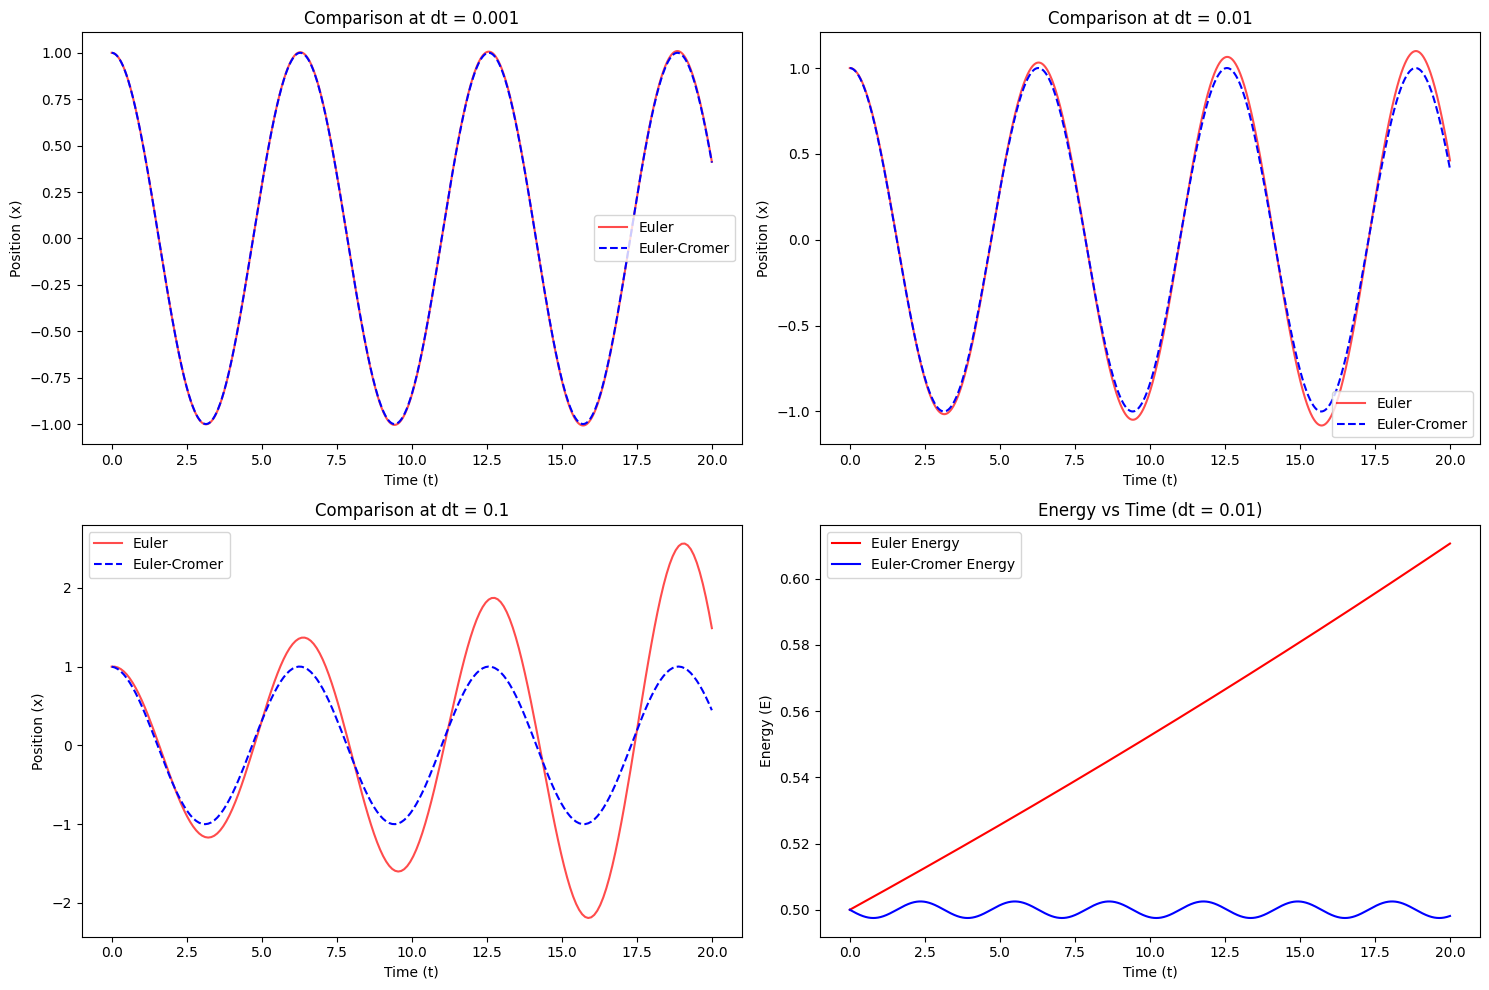

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def euler(x0, v0, dt, T):
    n_steps = int(T / dt)
    t = np.linspace(0, T, n_steps)
    x, v = np.zeros(n_steps), np.zeros(n_steps)
    x[0], v[0] = x0, v0
    for i in range(n_steps - 1):
        v[i+1] = v[i] - dt * x[i]
        x[i+1] = x[i] + dt * v[i]
    return t, x, v

def euler_cromer(x0, v0, dt, T):
    n_steps = int(T / dt)
    t = np.linspace(0, T, n_steps)
    x, v = np.zeros(n_steps), np.zeros(n_steps)
    x[0], v[0] = x0, v0
    for i in range(n_steps - 1):
        v[i+1] = v[i] - dt * x[i]
        x[i+1] = x[i] + dt * v[i+1]
    return t, x, v

x0, v0 = 1.0, 0.0
T = 20.0
dts = [0.001, 0.01, 0.1]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, dt in enumerate(dts):
    t_e, x_e, _ = euler(x0, v0, dt, T)
    t_ec, x_ec, _ = euler_cromer(x0, v0, dt, T)

    axes[i].plot(t_e, x_e, label='Euler', color='red', alpha=0.7)
    axes[i].plot(t_ec, x_ec, label='Euler-Cromer', color='blue', linestyle='--')
    axes[i].set_title(f'Comparison at dt = {dt}')
    axes[i].set_xlabel('Time (t)')
    axes[i].set_ylabel('Position (x)')
    axes[i].legend()

dt_en = 0.01
t_e, x_e, v_e = euler(x0, v0, dt_en, T)
t_ec, x_ec, v_ec = euler_cromer(x0, v0, dt_en, T)

e_euler = 0.5 * (v_e**2 + x_e**2)
e_cromer = 0.5 * (v_ec**2 + x_ec**2)

axes[3].plot(t_e, e_euler, label='Euler Energy', color='red')
axes[3].plot(t_ec, e_cromer, label='Euler-Cromer Energy', color='blue')
axes[3].set_title(f'Energy vs Time (dt = {dt_en})')
axes[3].set_xlabel('Time (t)')
axes[3].set_ylabel('Energy (E)')
axes[3].legend()

plt.tight_layout()
plt.show()

2. To see why the Euler-Cromer method is better at conserving energy, compute and show that,

$$E_{n+1} - E_n = \frac{1}{2}(v_n^2 - x_n^2)(\Delta t)^2 - v_n x_n (\Delta t)^3 + \frac{1}{2}x_n^2(\Delta t)^4.$$

  To see why this is an improvement for oscillatory problems, it is best to consider the simple harmonic motion in eqn.(1). Show that the coefficients of $(\Delta t)^2$ and $(\Delta t)^3$ average to zero over one time period (cycle), so that the Euler-Cromer method conserves energy up to $(\Delta t)^4$.

3. The equation of motion of the damped oscillator is given by $\ddot{x} + 2b\dot{x} + \omega_0^2x = 0$.Solve this differential equation for $x(0) = 0$, $v(0) = 1$, setting $\omega_0 = 1$, and up to at least three complete cycles. Adjust $b$ suitably and plot $t$ vs $x(t)$ (using Euler-Cromer algorithm) for underdamped, overdamped and critically damped oscillations.

###Hand Analysis

The differential equation given is:

$$\ddot{x} + 2b\dot{x} + \omega_0^2x = 0$$

Let we take a trial solution as $x = e^{rt}$.

Therefore, we get a quadratic equation as,

$$r^2 + 2br + \omega_0^2 = 0$$

Hence, we get a solution as:
$$r = -b \pm \sqrt{b^2 - \omega_o^2}$$

Thus, x becomes
$$x = e^{-bt} \left( A e^{\sqrt{b^2 - \omega_0^2}t} + B e^{-\sqrt{b^2 - \omega_0^2}t} \right)$$

Now, we have been given $w_o=1$,
$$x = e^{-bt} \left( A e^{\sqrt{b^2 - 1}t} + B e^{-\sqrt{b^2 - 1}t} \right)$$


###Case I: Underdamped ($b < 1$)
In this case, the term under the square root is negative, leading to imaginary roots and oscillatory motion. $$x(t) = e^{-bt} (A \cos(\omega_1 t) + B \sin(\omega_1 t))$$

Where: $\omega_1 = \sqrt{1 - b^2}$


###Case II: Overdamped ($b > 1$)
The roots are real and distinct, resulting in pure exponential decay without oscillation. $$x(t) = A e^{(-b + \sqrt{b^2 - 1})t} + B e^{(-b - \sqrt{b^2 - 1})t}$$

###Case III: Critically Damped ($b = 1$)
The roots are repeated ($r = -b$), requiring a $t$ term to maintain two independent constants.Formula: $$x(t) = (A + Bt)e^{-bt}$$


##Numerical Analysis

To perform numerical analysis, we must first break the second-order equation into two first-order equations:$$\frac{dx}{dt} = v$$ $$\frac{dv}{dt} = -2bv - \omega_0^2x$$

Now we apply Euler Chromer Method,
$$v_{n+1} = v_n - \Delta t x_n,$$$$x_{n+1} = x_n + \Delta t v_{n+1},$$

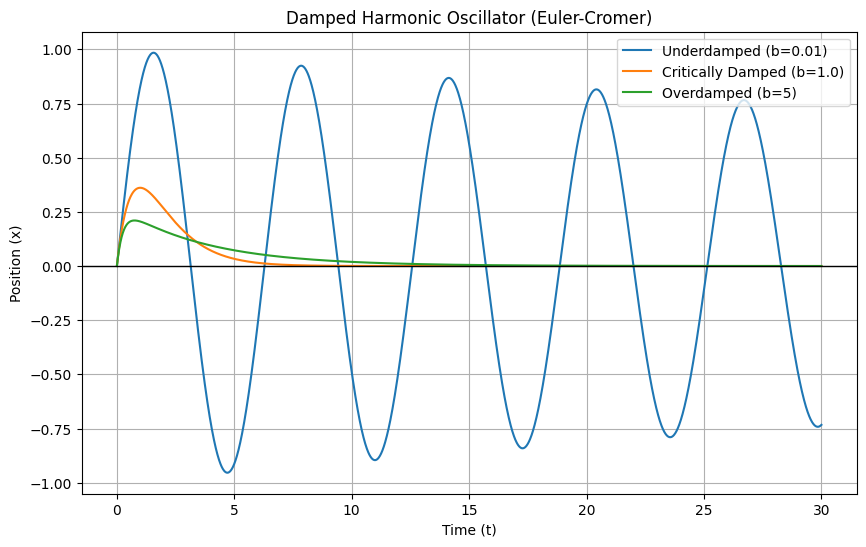

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def solve_damped(b, x0, v0, omega0, dt, T):
    n_steps = int(T / dt)
    t = np.linspace(0, T, n_steps)
    x = np.zeros(n_steps)
    v = np.zeros(n_steps)
    x[0], v[0] = x0, v0
    for i in range(n_steps - 1):
        v[i+1] = v[i] + (-2*b*v[i] - (omega0**2)*x[i]) * dt
        x[i+1] = x[i] + v[i+1] * dt
    return t, x

x0, v0 = 0.0, 1.0
omega0 = 1.0
dt = 0.01
T = 30.0

cases = {
    "Underdamped (b=0.01)": 0.01,
    "Critically Damped (b=1.0)": 1.0,
    "Overdamped (b=5)": 2
}

plt.figure(figsize=(10, 6))

for label, b_val in cases.items():
    t, x = solve_damped(b_val, x0, v0, omega0, dt, T)
    plt.plot(t, x, label=label)

plt.axhline(0, color='black', lw=1)
plt.title("Damped Harmonic Oscillator (Euler-Cromer)")
plt.xlabel("Time (t)")
plt.ylabel("Position (x)")
plt.legend()
plt.grid(True)
plt.show()

##Observations

* Underdamped:
This occurs when the resistance from the surrounding fluid is light, such as air or a thin liquid. The system retains enough energy to continue moving past the center point, resulting in several back-and-forth swings. However, because some energy is steadily transferred to the fluid as heat through friction, the height of each subsequent swing gradually decreases until the object eventually settles at the center.

* Overdamped: This happens when the medium is very thick or heavy, like thick motor oil. The resistance is so dominant that the object struggles to move through it at all. It lacks the momentum to ever cross the center point; instead, it slowly and steadily creeps back toward the equilibrium position, never actually oscillating.

* Criticaly Damped: It is the most efficient state because it provides just enough resistance to prevent any overshoot or swinging, while still allowing the object to return to its original resting position in the minimum amount of time possible.